In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
# import workCon
# import workCon_linearsys as workCon
# from eval import get_model_from_run
from tqdm import tqdm
import ipdb
import traceback
import random
import math
from scipy.integrate import solve_ivp
import pickle
import re

# asadas
from models_cartpole import RNNModel
from munch import Munch
import yaml
import importlib.util

os.environ["CUDA_VISIBLE_DEVICES"] = "3"


/home/phoenixw/.conda/envs/icl_ebonye_pendulum_new/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def mse(theta_model, thetadot_model, theta_rk4, thetadot_rk4):
    xs_pred = torch.tensor(np.column_stack((theta_model, thetadot_model)), dtype=torch.float32)
    xs_true = torch.tensor(np.column_stack((theta_rk4, thetadot_rk4)), dtype=torch.float32)
    return (xs_true - xs_pred).pow(2).mean().item()

def load_data(data_path):
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    return data

In [4]:
def _total_energy(theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
    # small helper (matches your conventions)
    c2 = np.cos(theta2)
    D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
    D12 = m2*(lc2**2 + l1*lc2*c2) + I2
    D22 = m2*lc2**2 + I2
    D = np.array([[D11, D12],[D12, D22]])
    dq = np.array([d1, d2])
    KE = 0.5 * dq @ (D @ dq)
    # T1 = 0.5 * I1 * d1**2
    # T2 = 0.5 * (m2 * l1**2 + I2 + 2*m2 * l1 * lc2 * c2) * d1**2 + 0.5 * I2 * d2**2 + (I2 + m2* l1 * lc2 * c2) * d1 * d2
    # KE = T1 + T2

    # U = -m1 * g * lc1 * np.cos(theta1 - np.pi/2.0) - m2 * g * (l1 * np.cos(theta1 - np.pi/2.0) + lc2 * np.cos(theta1 + theta2 - np.pi/2.0))
    # PE = U  # potential energy (up is negative; consistent with physics)

    # potential energy (up is positive; consistent with gym)
    y1 = lc1 * np.cos(theta1 - np.pi/2.0)
    y_tip = l1 * np.cos(theta1 - np.pi/2.0)
    y2 = y_tip + lc2 * np.cos(theta1 + theta2 - np.pi/2.0)
    PE = m1 * 9.81 * y1 + m2 * 9.81 * y2
    # return KE + PE
    return KE, PE

def _total_energy_batch(theta1, theta2, d1, d2,
                  m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
    """
    Vectorized total energy for acrobot (PyTorch version).
    
    Parameters:
        theta1, theta2, d1, d2 : float or tensor, shape (N,) or scalar
        m1, m2, l1, lc1, lc2, I1, I2 : float or tensor, shape (N,) or scalar
        g : gravity (float)
    
    Returns:
        Total energy (N,) tensor if inputs are batched, else scalar tensor.
    """

    # Convert everything to tensors on the same device/dtype
    device = (theta1.device if isinstance(theta1, torch.Tensor)
              else torch.device("cuda:0"))
    dtype = (theta1.dtype if isinstance(theta1, torch.Tensor)
             else torch.float32)

    def ensure_tensor(x):
        return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

    theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = map(
        ensure_tensor, (theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2)
    )

    # Broadcast to common shape
    theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = torch.broadcast_tensors(
        theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2
    )

    # Kinetic energy
    c2 = torch.cos(theta2)
    D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
    D12 = m2*(lc2**2 + l1*lc2*c2) + I2
    D22 = m2*lc2**2 + I2

    dq = torch.stack([d1, d2], dim=-1)  # (N, 2)
    D = torch.stack([
        torch.stack([D11, D12], dim=-1),
        torch.stack([D12, D22], dim=-1)
    ], dim=-2)  # (N, 2, 2)

    KE = 0.5 * torch.einsum("...i,...ij,...j->...", dq, D, dq)

    

    # Potential energy
    y1 = lc1 * torch.cos(theta1 - torch.pi/2.0)
    y_tip = l1 * torch.cos(theta1 - torch.pi/2.0)
    y2 = y_tip + lc2 * torch.cos(theta1 + theta2 - torch.pi/2.0)

    PE = m1 * g * y1 + m2 * g * y2

    return KE.cpu().numpy(), PE.cpu().numpy()

In [5]:
def stability_metric(states, K=20):
    """
    Computes the stability metric for a given set of states.

    Args:
        states (np.ndarray): Array of shape (T, state_dim) representing the states over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        float: The computed stability metric, representing the average deviation from goal state of last K steps.
    """
    if states.shape[0] < K + 1:
        raise ValueError("The number of time steps in states must be greater than K.")
    
    # Extract the last K states
    final_states = states[-K:]

    # convert angles to cosine and sine
    final_states = final_states.cpu().numpy() if torch.is_tensor(final_states) else final_states
    xs_cos1 = np.cos(final_states[:, 0])
    xs_sin1 = np.sin(final_states[:, 0])
    xs_cos2 = np.cos(final_states[:, 1])
    xs_sin2 = np.sin(final_states[:, 1])
    xs1dot = final_states[:, 2]
    xs2dot = final_states[:, 3]
    final_states_transformed = np.column_stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot))
    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]

    # Compute the Euclidean distance from the goal state for each of the last K states
    distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
    return np.mean(distances)

def stability_metric_batch(states_batch, K=20):
    """
    Computes the stability metric for a batch of states.

    Args:
        states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        np.ndarray: Array of shape (N,) containing the stability metric for each sequence.
    """
    if isinstance(states_batch, torch.Tensor):
        states_batch = states_batch.cpu().numpy()
    
    final_states = states_batch[:, -K:, :]
    xs_cos1 = np.cos(final_states[:, :, 0])
    xs_sin1 = np.sin(final_states[:, :, 0])
    xs_cos2 = np.cos(final_states[:, :, 1])
    xs_sin2 = np.sin(final_states[:, :, 1])
    xs1dot = final_states[:, :, 2]
    xs2dot = final_states[:, :, 3]
    final_states_transformed = np.stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot), axis=-1)

    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    distances = np.linalg.norm(final_states_transformed - goal_state, axis=-1)
    return np.mean(distances, axis=1)

def swinging_metric_batch(control_labels):
    """
    Computes the swinging metric for a batch of control labels.

    Args:
        control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of control inputs over time.
    Returns:
        np.ndarray: Array of shape (N,) containing the swinging metric for each sequence.
    """
    if isinstance(control_labels, torch.Tensor):
        control_labels = control_labels.cpu().numpy()
    
    # Compute the sum of time steps where controller is in swing-up mode (control label == 0)
    mask = (control_labels == 0)
    swinging_durations = np.sum(mask, axis=1)
    return swinging_durations

def swinging_difference_batch(true_control_labels, predicted_control_labels):
    """
    Compares swinging of true controller versus predicted control sequence.

    Args:
        true_control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of true control inputs over time.
        predicted_control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of predicted control inputs over time.

    """
    if isinstance(true_control_labels, torch.Tensor):
        true_control_labels = true_control_labels.cpu().numpy()
    if isinstance(predicted_control_labels, torch.Tensor):
        predicted_control_labels = predicted_control_labels.cpu().numpy()

    # Compute the difference in swinging durations
    true_swinging = swinging_metric_batch(true_control_labels)
    predicted_swinging = swinging_metric_batch(predicted_control_labels)
    return np.abs(true_swinging - predicted_swinging)

def stability_fraction_batch(predicted_states, K=20, threshold=0.1):
    """
    Computes the fraction of systems that are stable in the last K time steps.
    Args:
        predicted_states (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        K (int): Number of final time steps to consider for the stability metric.
        threshold (float): Distance threshold to consider a system as stable.
    Returns:
        float: Fraction of systems that are stable.
    """
    if isinstance(predicted_states, torch.Tensor):
        predicted_states = predicted_states.cpu().numpy()
    
    N = predicted_states.shape[0]
    stable_count = 0
    # goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    goal_state = np.array([0, 0, 1, 0, 0]) # [0, 0, cos(0), sin(0), 0]
    for i in range(N):
        final_states = predicted_states[i, -K:, :]
        # xs_cos1 = np.cos(final_states[:, 0])
        # xs_sin1 = np.sin(final_states[:, 0])
        # xs_cos2 = np.cos(final_states[:, 1])
        # xs_sin2 = np.sin(final_states[:, 1])
        # xs1dot = final_states[:, 2]
        # xs2dot = final_states[:, 3]
        xs_x = final_states[:, 0]
        xs_xdot = final_states[:, 1]
        xs_costheta = np.cos(final_states[:, 2])
        xs_sintheta = np.sin(final_states[:, 2])
        xs_thetadot = final_states[:, 3]
        final_states_transformed = np.column_stack((xs_x, xs_xdot, xs_costheta, xs_sintheta, xs_thetadot))
        # distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
        # import pdb; pdb.set_trace()
        # if np.all(distances < threshold):
        if np.all(np.abs(np.sin(final_states[:,2])) < 0.2) and np.all(np.abs(final_states[:,3]) < 0.3):
            stable_count += 1
    return stable_count / N

def stability_fraction_all_contexts_batch(predicted_states_dict, K=20, threshold=0.1):
    """
    Computes the fraction of systems that are stable in the last K time steps for all attempts.
    Args:
        predicted_states_dict (dict): Dictionary where keys are context identifiers and values are arrays of shape (N, T, state_dim) representing N sequences of states over time for that context.
        K (int): Number of final time steps to consider for the stability metric.
        threshold (float): Distance threshold to consider a system as stable.
    Returns:
        float: Fraction of systems that are stable in at least one context.
    """
    contexts = list(predicted_states_dict.keys())
    N = predicted_states_dict[contexts[0]].shape[0]
    stable_count = 0
    total_count = 0
    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    for i in range(N):
        is_stable = False
        for context in contexts:
            predicted_states = predicted_states_dict[context].cpu().numpy() if torch.is_tensor(predicted_states_dict[context]) else predicted_states_dict[context]
            final_states = predicted_states[i, -K:, :]
            # xs_cos1 = np.cos(final_states[:, 0])
            # xs_sin1 = np.sin(final_states[:, 0])
            # xs_cos2 = np.cos(final_states[:, 1])
            # xs_sin2 = np.sin(final_states[:, 1])
            # xs1dot = final_states[:, 2]
            # xs2dot = final_states[:, 3]
            xs_x = final_states[:, 0]
            xs_xdot = final_states[:, 1]
            xs_costheta = np.cos(final_states[:, 2])
            xs_sintheta = np.sin(final_states[:, 2])
            xs_thetadot = final_states[:, 3]
            final_states_transformed = np.column_stack((xs_x, xs_xdot, xs_costheta, xs_sintheta, xs_thetadot))
            distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
            # if np.all(distances < threshold):
            if np.all(np.abs(np.sin(final_states[:,2])) < 0.2) and np.all(np.abs(final_states[:,3]) < 0.2):
                # is_stable = True
                # break
                stable_count += 1
            total_count += 1
        # if is_stable:
            # stable_count += 1
    # return stable_count / N
    print(f"Stable count: {stable_count}, Total count: {total_count}")
    return stable_count / total_count

def energy_metric_batch(true_states_batch, predicted_states_batch, link_lengths1, link_lengths2, link_masses1, link_masses2):
    """
    Computes the difference in total energy for true vs predicted trajectories.
    Args:
        true_states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of true states over time.
        predicted_states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of predicted states over time.
        link_lengths1 (float or np.ndarray): Length(s) of the first link(s).
        link_lengths2 (float or np.ndarray): Length(s) of the second link(s).
        link_masses1 (float or np.ndarray): Mass(es) of the first link(s).
        link_masses2 (float or np.ndarray): Mass(es) of the second link(s).
    Returns:
        np.ndarray: Array of shape (N,) containing the average energy difference for each sequence.
    """
    if isinstance(true_states_batch, torch.Tensor):
        true_states_batch = true_states_batch.cpu().numpy()
    if isinstance(predicted_states_batch, torch.Tensor):
        predicted_states_batch = predicted_states_batch.cpu().numpy()
    
    theta1_true = true_states_batch[:, :, 0]
    theta2_true = true_states_batch[:, :, 1]
    d1_true = true_states_batch[:, :, 2]
    d2_true = true_states_batch[:, :, 3]

    theta1_pred = predicted_states_batch[:, :, 0]
    theta2_pred = predicted_states_batch[:, :, 1]
    d1_pred = predicted_states_batch[:, :, 2]
    d2_pred = predicted_states_batch[:, :, 3]

    # KE_true, PE_true = _total_energy_batch(theta1_true, theta2_true, d1_true, d2_true,
    #                                        link_masses1, link_masses2,
    #                                        link_lengths1, link_lengths1/2, link_lengths2/2,
    #                                        (1/12)*link_masses1*link_lengths1**2,
    #                                        (1/12)*link_masses2*link_lengths2**2)
    # KE_pred, PE_pred = _total_energy_batch(theta1_pred, theta2_pred, d1_pred, d2_pred,
    #                                        link_masses1, link_masses2,
    #                                        link_lengths1, link_lengths1/2, link_lengths2/2,
    #                                        (1/12)*link_masses1*link_lengths1**2,
    #                                        (1/12)*link_masses2*link_lengths2**2)

    for i in range(true_states_batch.shape[1]):
        KE_true, PE_true = _total_energy_batch(theta1_true[:, i], theta2_true[:, i], d1_true[:, i], d2_true[:, i],
                                           link_masses1, link_masses2,
                                           link_lengths1, link_lengths1/2, link_lengths2/2,
                                           (1/12)*link_masses1*link_lengths1**2,
                                           (1/12)*link_masses2*link_lengths2**2)
        KE_pred, PE_pred = _total_energy_batch(theta1_pred[:, i], theta2_pred[:, i], d1_pred[:, i], d2_pred[:, i],
                                           link_masses1, link_masses2,
                                           link_lengths1, link_lengths1/2, link_lengths2/2,
                                           (1/12)*link_masses1*link_lengths1**2,
                                           (1/12)*link_masses2*link_lengths2**2)
        if i == 0:
            KE_true_all = KE_true[:, None]
            PE_true_all = PE_true[:, None]
            KE_pred_all = KE_pred[:, None]
            PE_pred_all = PE_pred[:, None]
        else:
            KE_true_all = np.concatenate((KE_true_all, KE_true[:, None]), axis=1)
            PE_true_all = np.concatenate((PE_true_all, PE_true[:, None]), axis=1)
            KE_pred_all = np.concatenate((KE_pred_all, KE_pred[:, None]), axis=1)
            PE_pred_all = np.concatenate((PE_pred_all, PE_pred[:, None]), axis=1)

    # total_energy_true = KE_true + PE_true
    # total_energy_pred = KE_pred + PE_pred

    # energy_diff = np.abs(total_energy_true - total_energy_pred)
    total_energy_true = KE_true_all + PE_true_all
    total_energy_pred = KE_pred_all + PE_pred_all
    energy_diff = np.abs(total_energy_true - total_energy_pred)
    # import pdb; pdb.set_trace()
    ## do l2 instead of l1
    
    return np.mean(energy_diff, axis=1)

def evaluate_metrics(states_batch, control_labels_batch, K=20):
    """
    Evaluates both stability and swinging metrics for a batch of states and control labels.

    Args:
        states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        control_labels_batch (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of control inputs over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        tuple: Two np.ndarrays of shape (N,) containing the stability and swinging metrics for each sequence.
    """
    stability_metrics = stability_metric_batch(states_batch, K)
    swinging_metrics = swinging_metric_batch(control_labels_batch)
    return stability_metrics, swinging_metrics

In [6]:
model_run_id = "three_layer_lstm_v3_h1024_e256_dropout"
step = 4800 
numberpend = 100 #200 #5
mode = "ood" # "ood" or "indistr"
data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'

steps_list = [4800, 25000, 50000, 75000, 100000, 200000]

contexts = [1, 5, 10, 25, 50]
mode = "indistr" # "indistr" or "ood"

results = {}
metrics = ['stability', 'swinging', 'energy', 'stability_fraction']
for metric in metrics:
    results[metric] = {}

In [7]:
data_path = f'./inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)

Contexts:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating metrics for context length: 1
Loaded data from inference_run/mse_control_4800_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_25000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_50000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_75000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_100000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl


Contexts:  20%|██        | 1/5 [00:02<00:11,  2.86s/it]

Loaded data from inference_run/mse_control_200000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Evaluating metrics for context length: 5
Loaded data from inference_run/mse_control_4800_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_25000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_50000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_75000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_100000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl


Contexts:  40%|████      | 2/5 [00:05<00:07,  2.53s/it]

...

Loaded data from inference_run/mse_control_200000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Evaluating metrics for context length: 25
Loaded data from inference_run/mse_control_4800_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_25000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_50000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_75000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_100000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl


Contexts:  80%|████████  | 4/5 [00:12<00:03,  3.36s/it]

Loaded data from inference_run/mse_control_200000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Evaluating metrics for context length: 50
Loaded data from inference_run/mse_control_4800_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_25000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_50000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_75000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_100000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl


Contexts: 100%|██████████| 5/5 [00:14<00:00,  2.99s/it]

Loaded data from inference_run/mse_control_200000_three_layer_lstm_v3_h1024_e256_dropout/results_maxcontext50_numpends100_indistr_alexcode.pkl


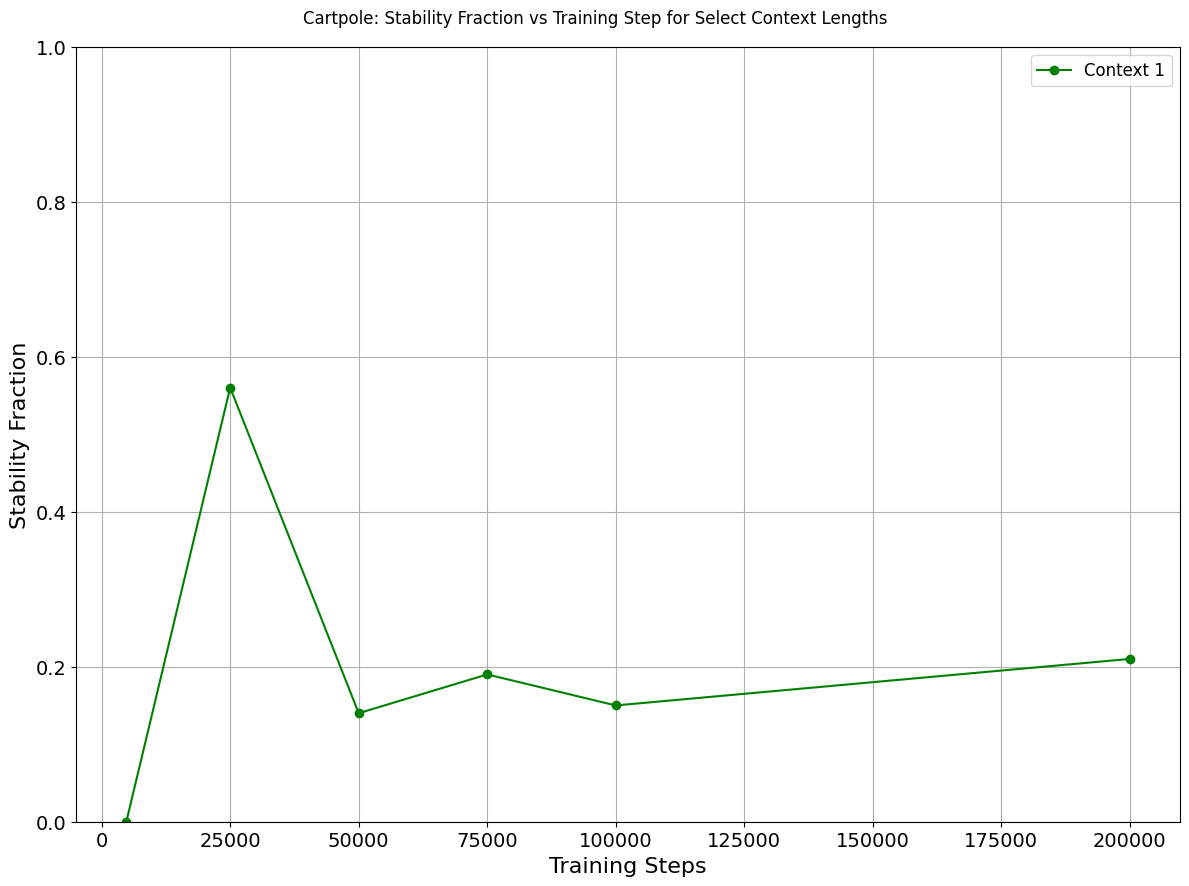

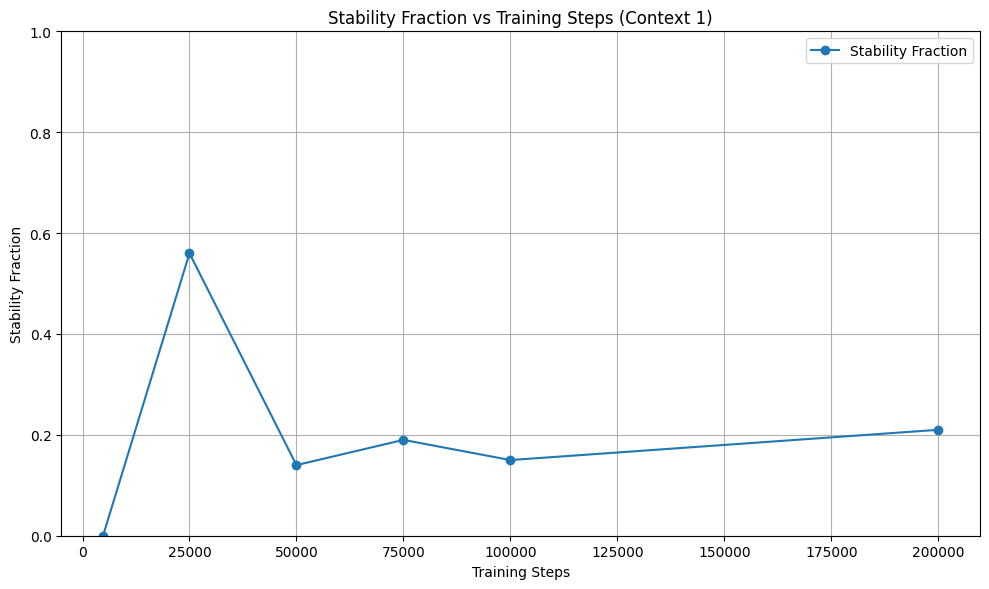

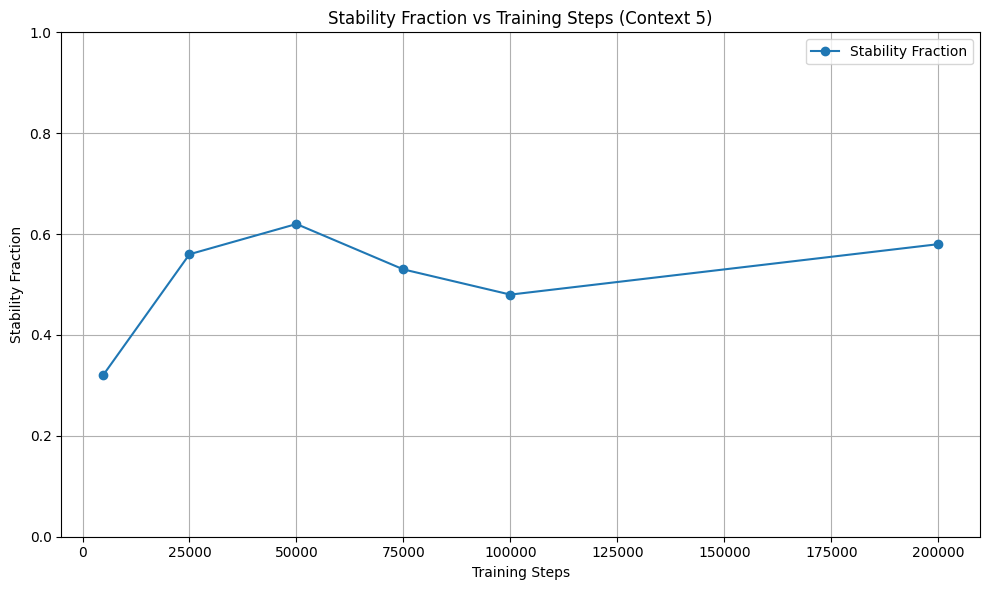

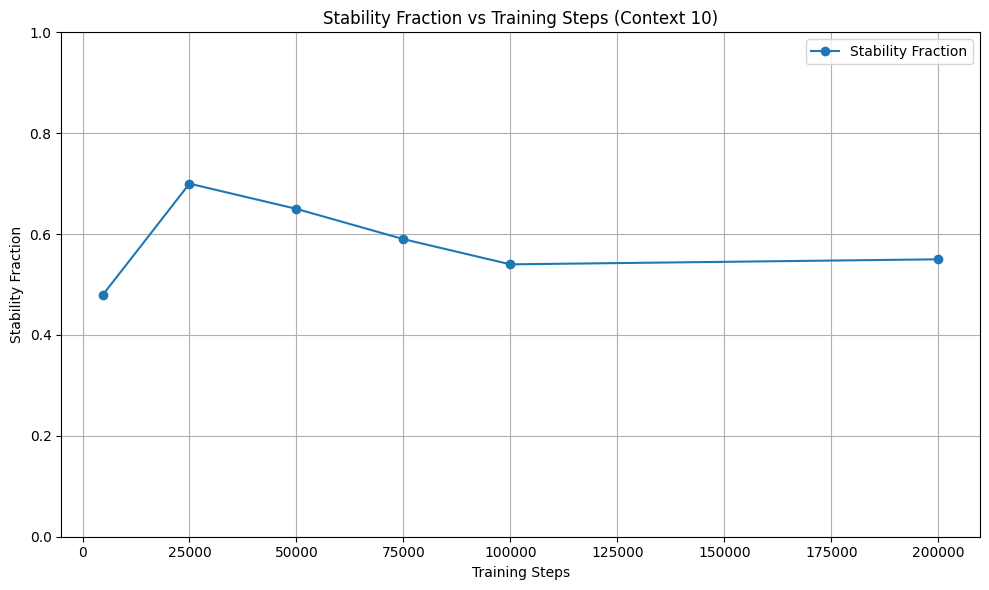

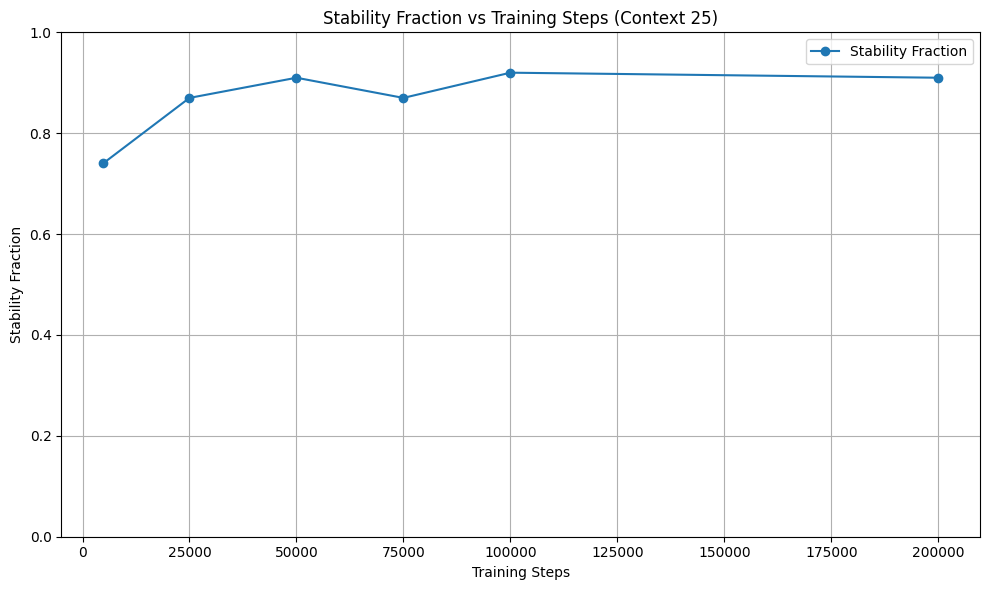

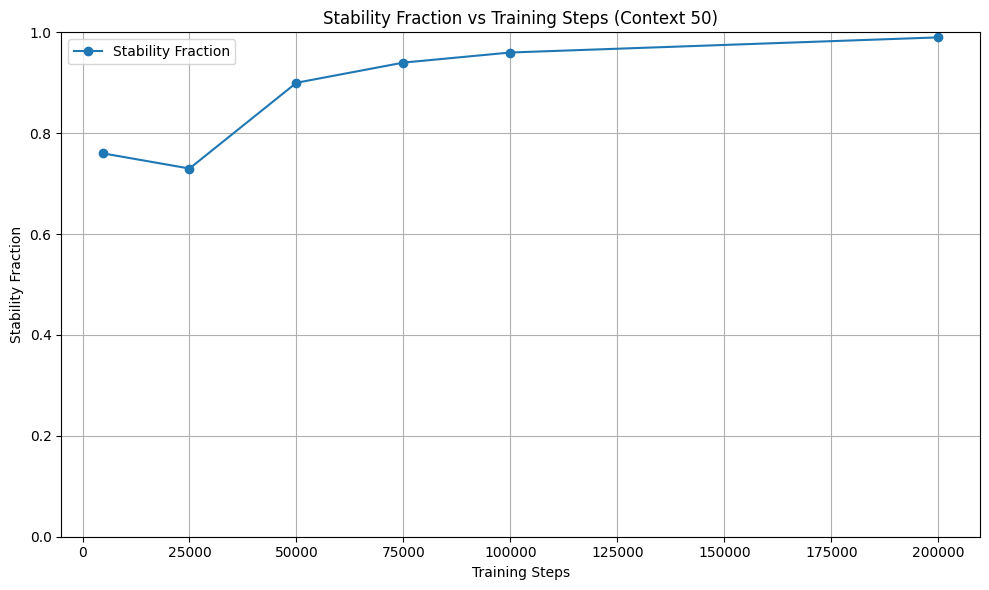

In [8]:
fig_select, ax_select = plt.subplots(figsize=(12, 9))
colors = ['green', 'orange', 'purple', 'brown']
select_contexts = [1, 6, 12, 20]
composite_images = []
from tqdm import tqdm
for context in tqdm(contexts, desc="Contexts"):
    print(f"Evaluating metrics for context length: {context}")
    for step in steps_list:
        data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
        cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
        print(f"Loaded data from {data_path}")

        pred_traj = torch.stack(phase_data[context])
        
        stability_metrics, swinging_metrics = evaluate_metrics(pred_traj, torch.stack(controls_data[context])[:,:,-1], K=100)
        
        ground_truth_data_controls = data_and_controls[0]
        ground_truth_control_labels = [ground_truth_data_controls[i][1][:,1][:-1] for i in range(len(ground_truth_data_controls))]
        true_traj = [ground_truth_data_controls[i][0] for i in range(len(ground_truth_data_controls))]
        true_traj = np.stack(true_traj)

        stability_fraction = stability_fraction_batch(pred_traj, K=10, threshold=0.3)

        median_stability = np.median(stability_metrics)
        mean_stability = np.mean(stability_metrics)
        twentyfifth_percentile = np.percentile(stability_metrics, 25)
        seventyfifth_percentile = np.percentile(stability_metrics, 75)

        median_swinging = np.median(swinging_metrics)
        mean_swinging = np.mean(swinging_metrics)
        twentyfifth_swinging = np.percentile(swinging_metrics, 25)
        seventyfifth_swinging = np.percentile(swinging_metrics, 75)

        results['stability'][step] = {
            'median': median_stability,
            '25th_percentile': twentyfifth_percentile,
            '75th_percentile': seventyfifth_percentile,
            'mean': mean_stability
        }

        results['swinging'][step] = {
            'median': median_swinging,
            '25th_percentile': twentyfifth_swinging,
            '75th_percentile': seventyfifth_swinging,
            'mean': mean_swinging

        }

        results['stability_fraction'][step] = stability_fraction

    # visulaize results
    import matplotlib.pyplot as plt
    import pandas as pd

    # prepare data for plotting
    data = []
    for step in steps_list:
        for metric in metrics:
            if metric == 'stability_fraction':
                data.append({
                    'metric': metric,
                    'step': step,
                    'value': results[metric][step]
                })
            else:
                pass

    df = pd.DataFrame(data)
    df = df.sort_values(by='step')
    fig = plt.figure(figsize=(10, 6))
    for metric in metrics:
        metric_data = df[df['metric'] == metric]
        if metric == 'stability_fraction':
            plt.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
            plt.title(f'Stability Fraction vs Training Steps (Context {context})')
            plt.xlabel('Training Steps')
            plt.ylabel('Stability Fraction')
            plt.ylim(0, 1)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()

            if context in select_contexts:
                ax_select.plot(metric_data['step'], metric_data['value'], label=f'Context {context}', marker='o', color=colors[select_contexts.index(context)])
                ax_select.set_xlabel('Training Steps', fontsize=16)
                ax_select.set_ylabel('Stability Fraction', fontsize=16)
                ax_select.set_ylim(0, 1)
                ax_select.tick_params(axis='x', labelsize=14)
                ax_select.tick_params(axis='y', labelsize=14)
                ax_select.legend(fontsize=12)
                ax_select.grid(True)
                plt.tight_layout()

            continue
        else:
            pass
    plt.tight_layout()

    fig_select.suptitle('Cartpole: Stability Fraction vs Training Step for Select Context Lengths')
    fig_select.tight_layout()
    output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems_mode{mode}'
    os.makedirs(output_dir, exist_ok=True)
    # fig_select.savefig(os.path.join(output_dir, f'stability_fraction_select_contexts_100systems_mode{mode}.png'))
    # fig_select.savefig(os.path.join(output_dir, f'stability_fraction_select_contexts_100systems_mode{mode}.pdf'), format='pdf', bbox_inches='tight')
    # plt.close(fig_select)

    # if context in select_contexts:
    #     figure, axis = plt.subplots(figsize=(10, 6))
    #     for metric in metrics:
    #         metric_data = df[df['metric'] == metric]
    #         if metric == 'stability_fraction':
    #             axis.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
    #             axis.set_title(f'Stability Fraction over Training Steps (Context {context})')
    #             axis.set_xlabel('Training Steps')
    #             axis.set_ylabel('Stability Fraction')
    #             axis.set_ylim(0, 1)
    #             axis.legend()
    #             axis.grid(True)
    #             plt.tight_layout()
    #     plt.suptitle(f'Stability Fraction across Context Lengths (Context {context})', y=1.02)
    #     plt.tight_layout()
    #     composite_images.append(figure)

    # create folder and save subplots
    # output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems'
    os.makedirs(output_dir, exist_ok=True)
    # folder = f"context{context}_100systems"
    # os.makedirs(os.path.join(output_dir, folder), exist_ok=True)
    # fig.savefig(os.path.join(output_dir, f'all_metrics_context{context}_100systems_mode{mode}.png'))
    
    # fig.savefig(os.path.join(output_dir, f'stability_fraction_context{context}_100systems_mode{mode}.pdf'), format='pdf', bbox_inches='tight')

In [9]:
steps_list2 = [10000, 17000]
model_run_id = "three_layer_lstm_v3_h1024_e256_dropout_retrain"
numberpend = 100 #200 #5
contexts = [1, 5, 10, 25, 50]
modes = ["indistr", "ood"]

results2 = {}
metrics2 = ['stability', 'swinging', 'energy', 'stability_fraction']
for metric in metrics2:
    results2[metric] = {}

for step in tqdm(steps_list2, desc="Steps2"):
    for ctx in contexts:
        for mode in modes:
            data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
            cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
            print(f"Loaded data from {data_path}")

            pred_traj = torch.stack(phase_data[ctx])
            
            stability_metrics, swinging_metrics = evaluate_metrics(pred_traj, torch.stack(controls_data[ctx])[:,:,-1], K=100)

            stability_fraction = stability_fraction_batch(pred_traj, K=10, threshold=0.3)

            median_stability = np.median(stability_metrics)
            mean_stability = np.mean(stability_metrics)
            twentyfifth_percentile = np.percentile(stability_metrics, 25)
            seventyfifth_percentile = np.percentile(stability_metrics, 75)

            median_swinging = np.median(swinging_metrics)
            mean_swinging = np.mean(swinging_metrics)
            twentyfifth_swinging = np.percentile(swinging_metrics, 25)
            seventyfifth_swinging = np.percentile(swinging_metrics, 75)

            results2['stability_fraction'][(step, ctx, mode)] = stability_fraction

Steps2:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded data from inference_run/mse_control_10000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_10000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_ood_alexcode.pkl
Loaded data from inference_run/mse_control_10000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_10000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_ood_alexcode.pkl
Loaded data from inference_run/mse_control_10000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_10000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_ood_alexcode.pkl
Loaded data from inference_run/mse_control_10000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxconte

Steps2:  50%|█████     | 1/2 [00:03<00:03,  3.49s/it]

Loaded data from inference_run/mse_control_10000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_ood_alexcode.pkl
Loaded data from inference_run/mse_control_17000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_17000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_ood_alexcode.pkl
Loaded data from inference_run/mse_control_17000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_17000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_ood_alexcode.pkl
Loaded data from inference_run/mse_control_17000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_17000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxconte

Steps2: 100%|██████████| 2/2 [00:10<00:00,  5.03s/it]

Loaded data from inference_run/mse_control_17000_three_layer_lstm_v3_h1024_e256_dropout_retrain/results_maxcontext50_numpends100_ood_alexcode.pkl


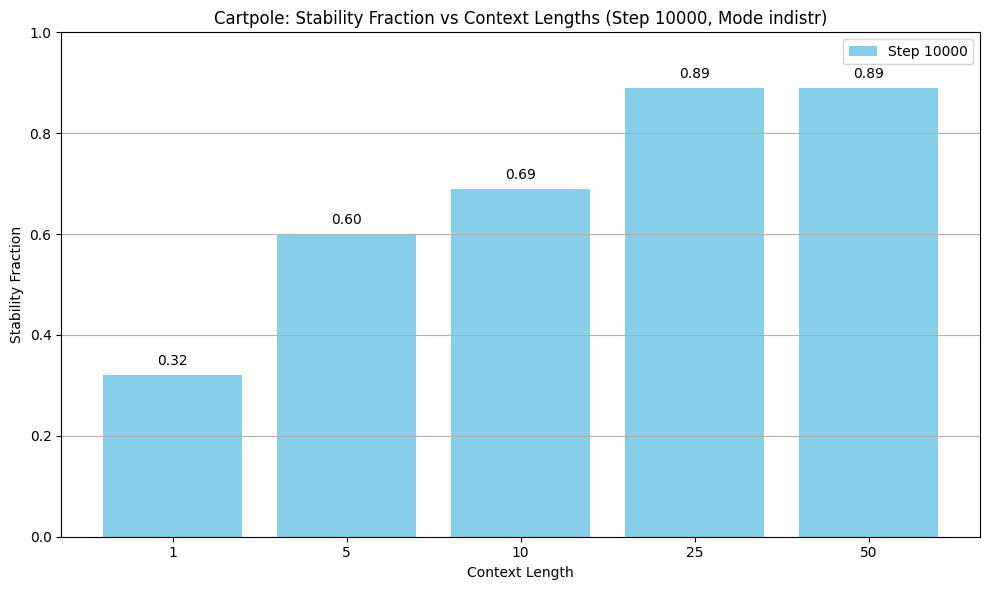

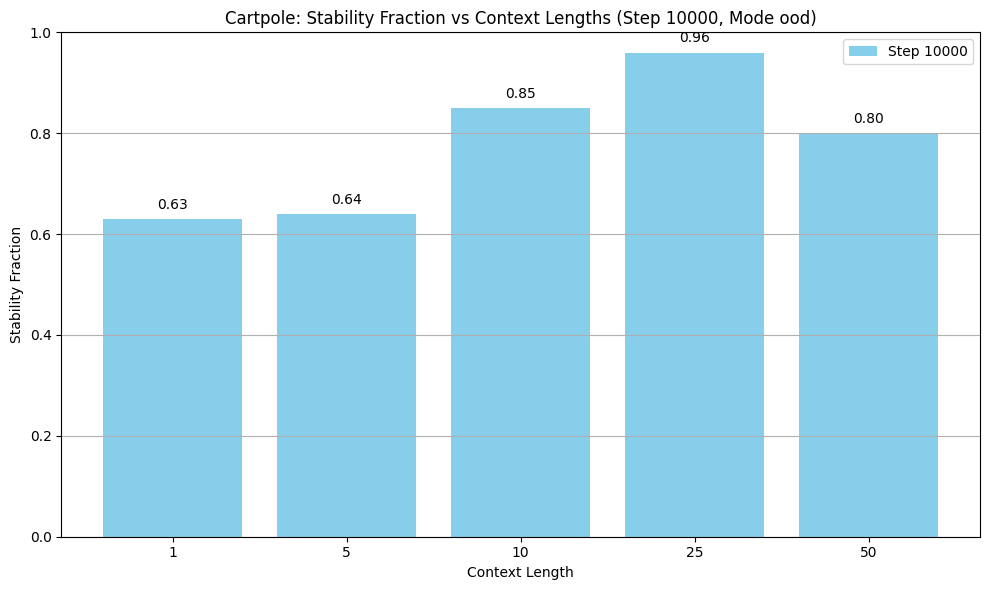

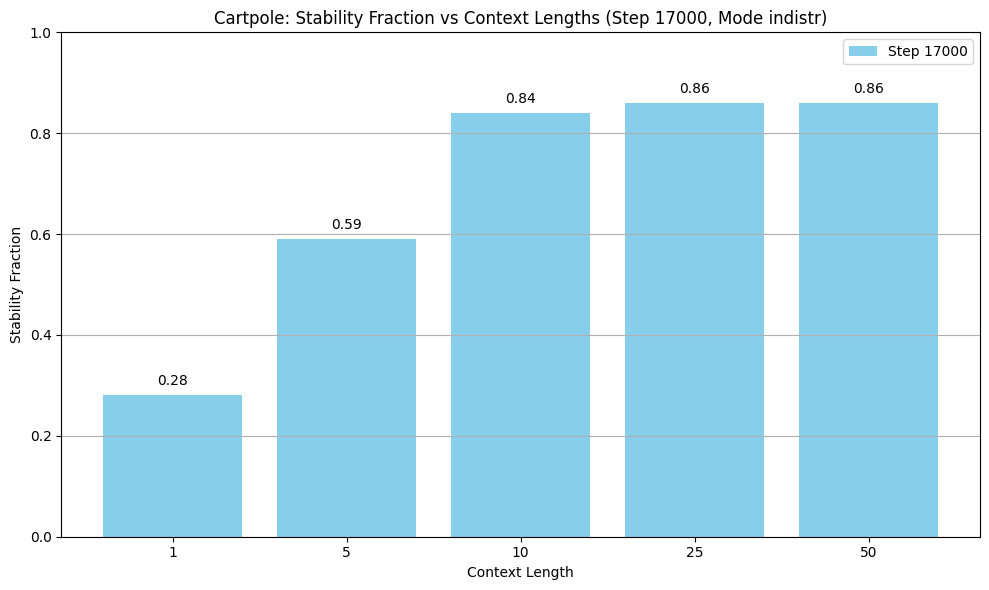

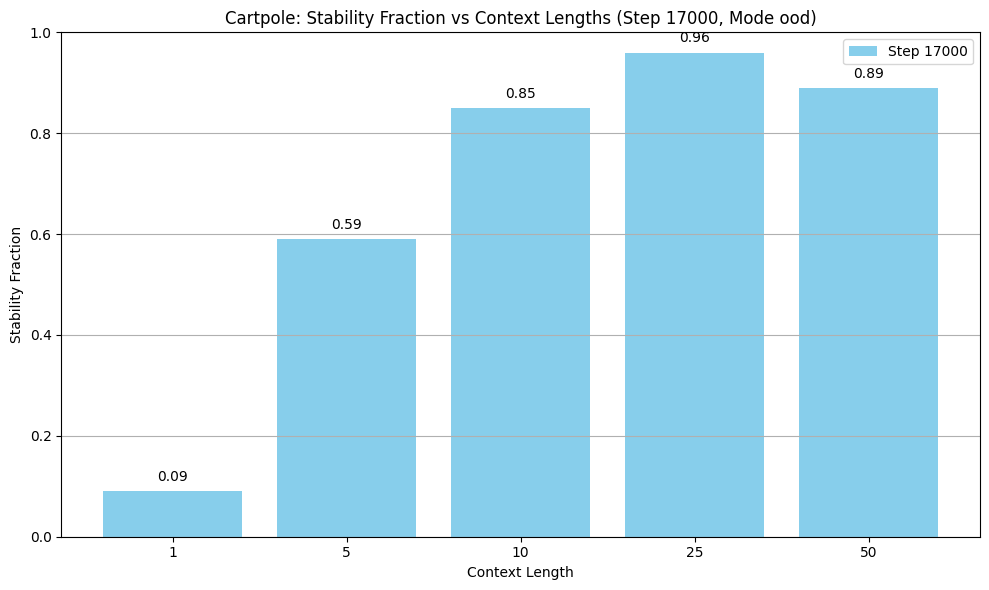

In [10]:
data2 = []
import matplotlib.pyplot as plt
import pandas as pd

for stp in steps_list2:
    for metric in metrics2:
        for ctx in contexts:
            for mode in modes:
                if metric == 'stability_fraction':
                    data2.append({
                        'metric': metric,
                        'step': stp,
                        'context': ctx,
                        'mode': mode,
                        'value': results2[metric][(stp, ctx, mode)]
                    })
                else:
                    pass


df2 = pd.DataFrame(data2)
df2 = df2.sort_values(by='context')

metric = 'stability_fraction'
metric_data = df2[df2['metric'] == metric]
for stp in steps_list2:
    for mode in modes:
        step_metric_data = metric_data[(metric_data['step'] == stp) & (metric_data['mode'] == mode)]
        
        # ax_ctx.plot(step_metric_data['context'], step_metric_data['value'], label=f'Step {stp}', marker='o')
        # ax_ctx.set_title(f'Cartpole: Stability Fraction vs Context Lengths (Step {stp})')
        # ax_ctx.set_xlabel('Context Length')
        # ax_ctx.set_ylabel('Stability Fraction')
        # ax_ctx.set_ylim(0, 1)
        # ax_ctx.set_xticks(contexts)
        # ax_ctx.set_xlim(1, max(contexts)+1)
        # ax_ctx.legend()
        # ax_ctx.grid(True)


        fig_ctx2, ax_ctx2 = plt.subplots(figsize=(10, 6))  # bar graph
        x_label_list = step_metric_data['context'].astype(str).tolist()  # Convert context values to strings for x-axis labels
        ax_ctx2.bar(x_label_list, step_metric_data['value'], label=f'Step {stp}', color='skyblue')
        ax_ctx2.set_title(f'Cartpole: Stability Fraction vs Context Lengths (Step {stp}, Mode {mode})')
        ax_ctx2.set_xlabel('Context Length')
        ax_ctx2.set_ylabel('Stability Fraction')
        ax_ctx2.set_ylim(0, 1)
        # ax_ctx2.set_xticks(contexts)
        # ax_ctx2.set_xlim(1, max(contexts)+1)
        ax_ctx2.legend()
        ax_ctx2.grid(True, axis='y')
        # add value labels on top of bars
        for i, v in enumerate(step_metric_data['value']):
            ax_ctx2.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)

        

        plt.tight_layout()
        plt.show()

        # create subfolder and save plot
        # output_dir = "test_plots_cartpole_temp"
        # os.makedirs(output_dir, exist_ok=True)
        # file_path_line_plot = os.path.join(output_dir, f'stability_fraction_vs_context_length_line_step{stp}_100systems_mode{mode}.png')
        # file_path_bar_plot = os.path.join(output_dir, f'stability_fraction_vs_context_length_bar_step{stp}_100systems_mode{mode}.png')
        # # fig_ctx.savefig(file_path_line_plot)
        # fig_ctx2.savefig(file_path_bar_plot)
        # print(f"Saved line plot to {file_path_line_plot}")
        # print(f"Saved bar plot to {file_path_bar_plot}")
        



# print(f"Data for metric '{metric}': {metric_data.head()}")
# ax_ctx.plot(metric_data['context'], metric_data['value'], label='Stability Fraction', marker='o')
# ax_ctx.set_title(f'Cartpole: Stability Fraction vs Context Lengths (Step {step})')
# ax_ctx.set_xlabel('Context Length')
# ax_ctx.set_ylabel('Stability Fraction')
# ax_ctx.set_ylim(0, 1)
# ax_ctx.set_xticks(contexts)
# ax_ctx.set_xlim(1, max(contexts)+1)
# ax_ctx.legend()
# ax_ctx.grid(True)
# plt.tight_layout()
# plt.show()

# # create subfolder and save plot
# output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems_mode{mode}'
# os.makedirs(output_dir, exist_ok=True)
# subfolder = f"contexts_vs_stability_fraction_100systems_mode{mode}"
# os.makedirs(os.path.join(output_dir, subfolder), exist_ok=True)
# # fig_ctx.savefig(os.path.join(output_dir, subfolder, f'stability_fraction_vs_context_length_step{step}_100systems_mode{mode}.png'))
# # fig_ctx.savefig(os.path.join(output_dir, subfolder, f'stability_fraction_vs_context_length_step{step}_100systems_mode{mode}.pdf'), format='pdf', bbox_inches='tight')

Saved paper-ready plot: stability_comparison_step10000_paper.png


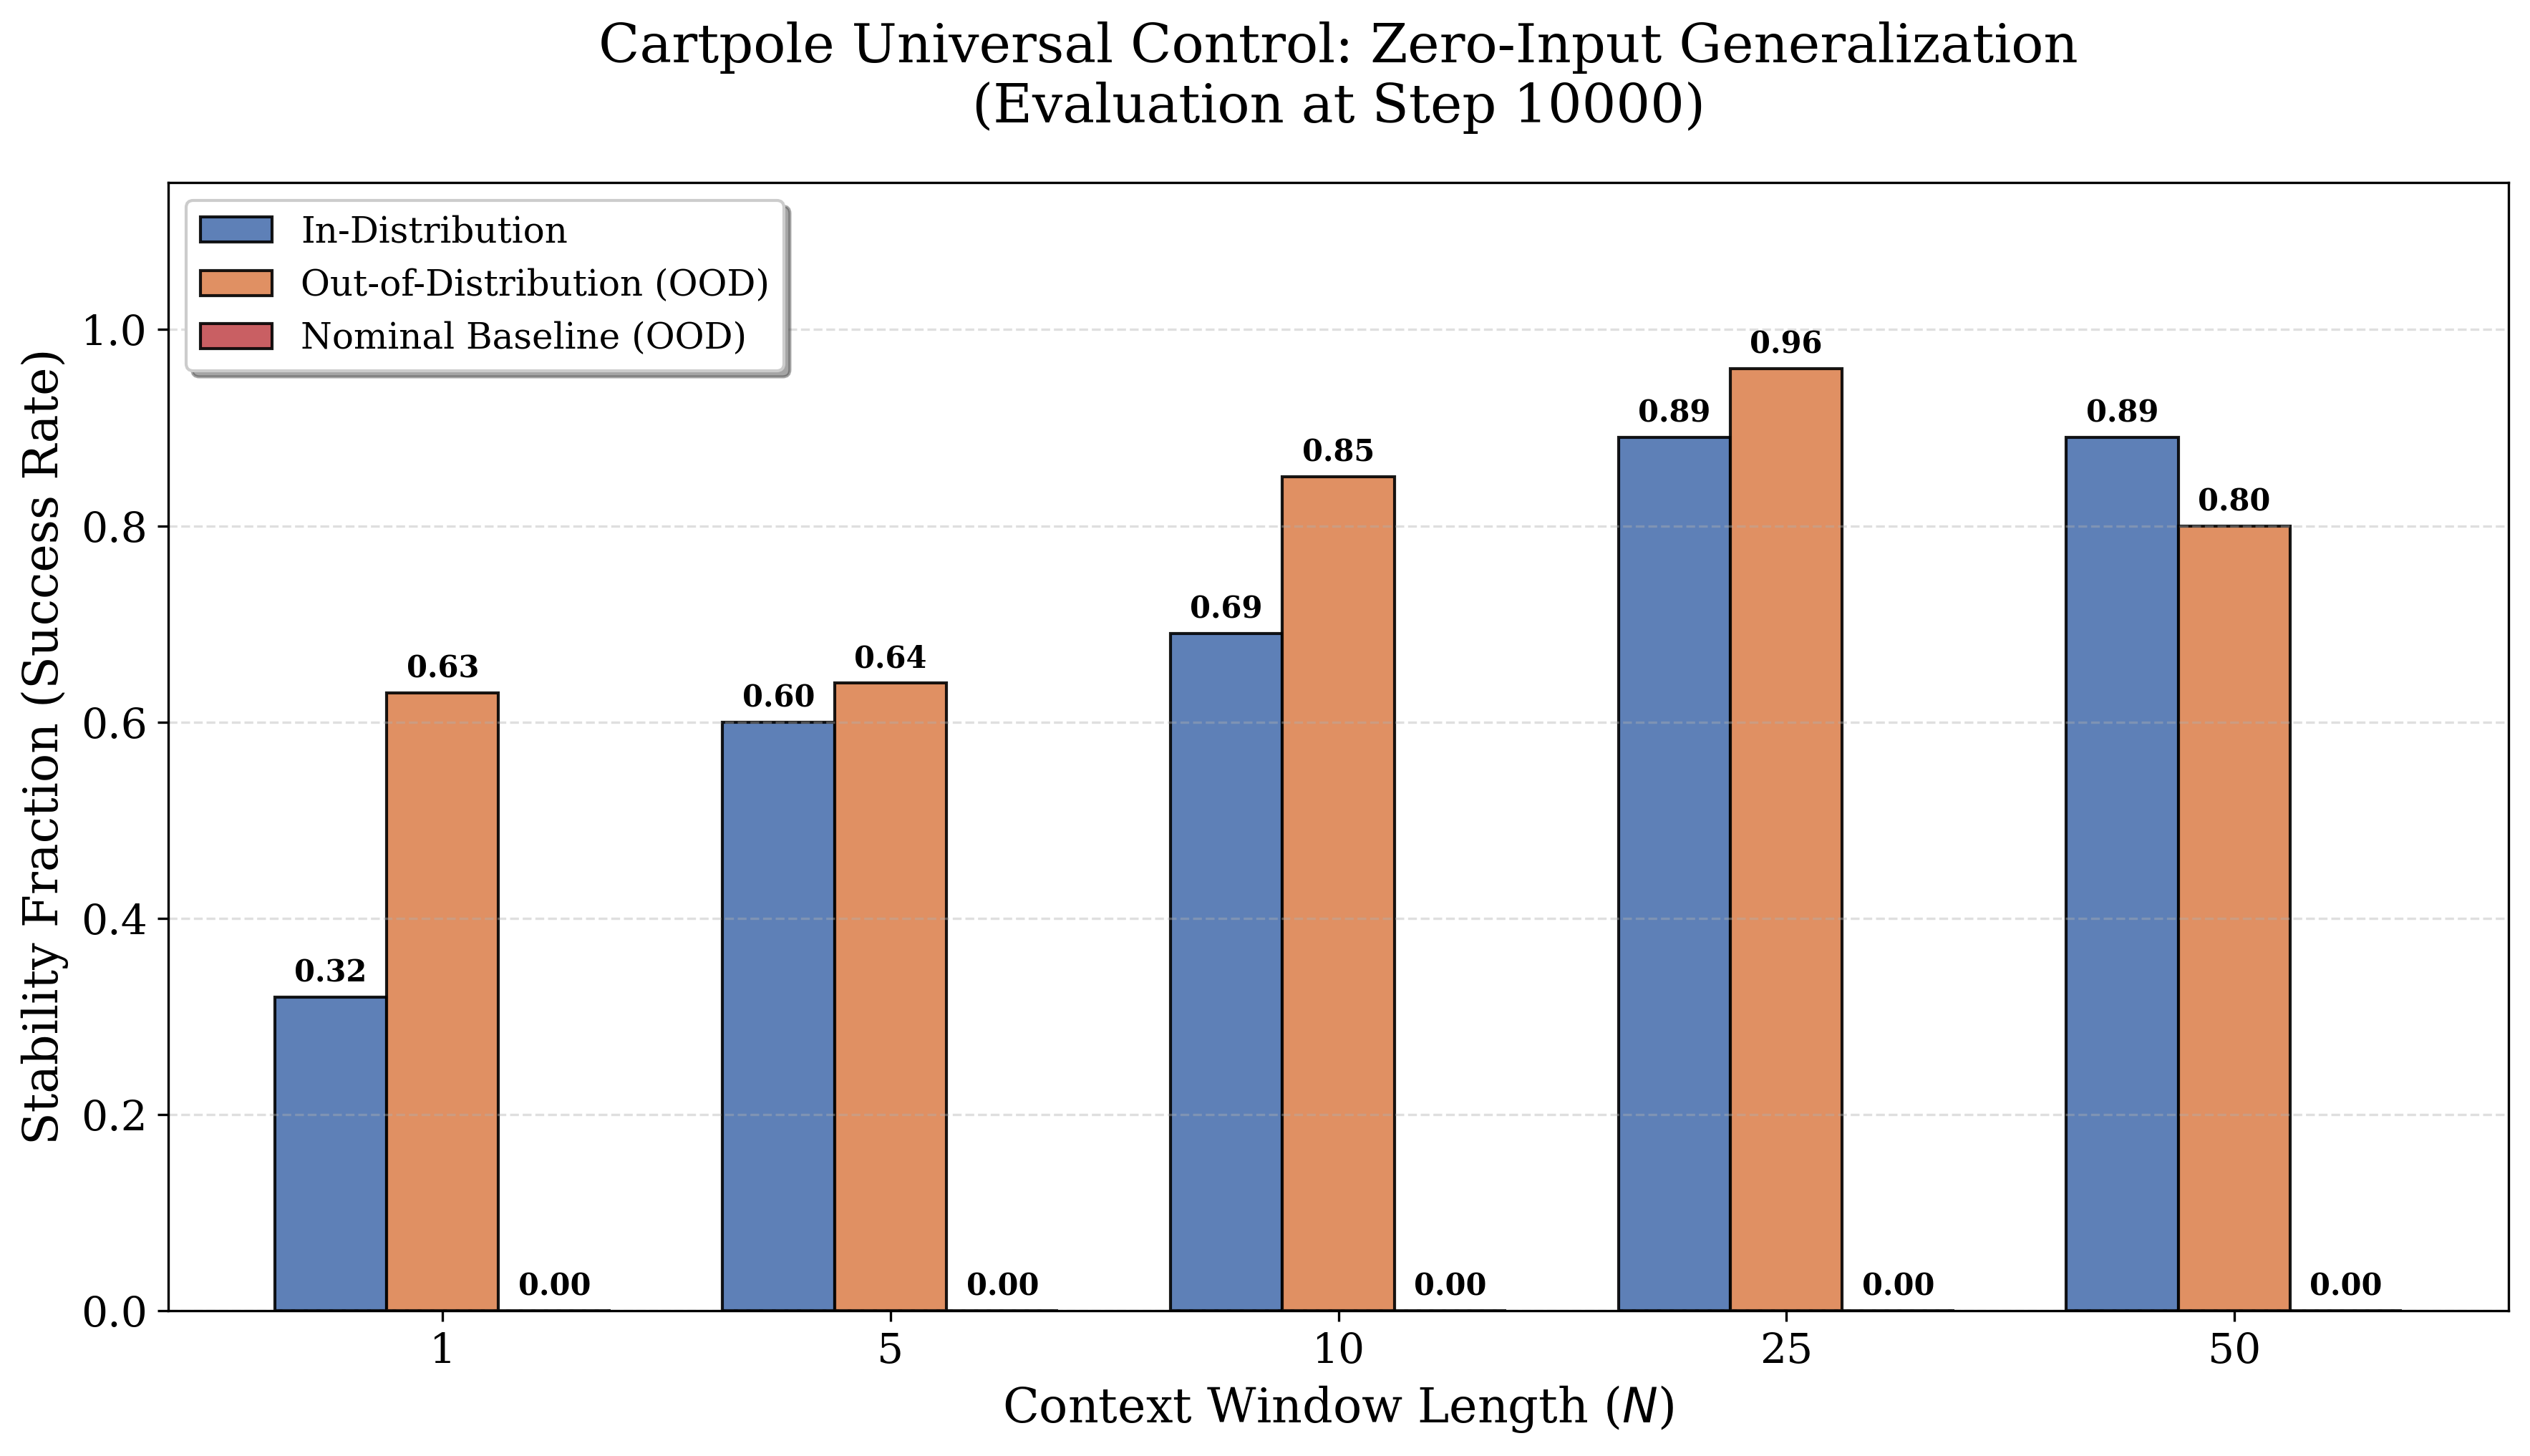

Saved paper-ready plot: stability_comparison_step17000_paper.png


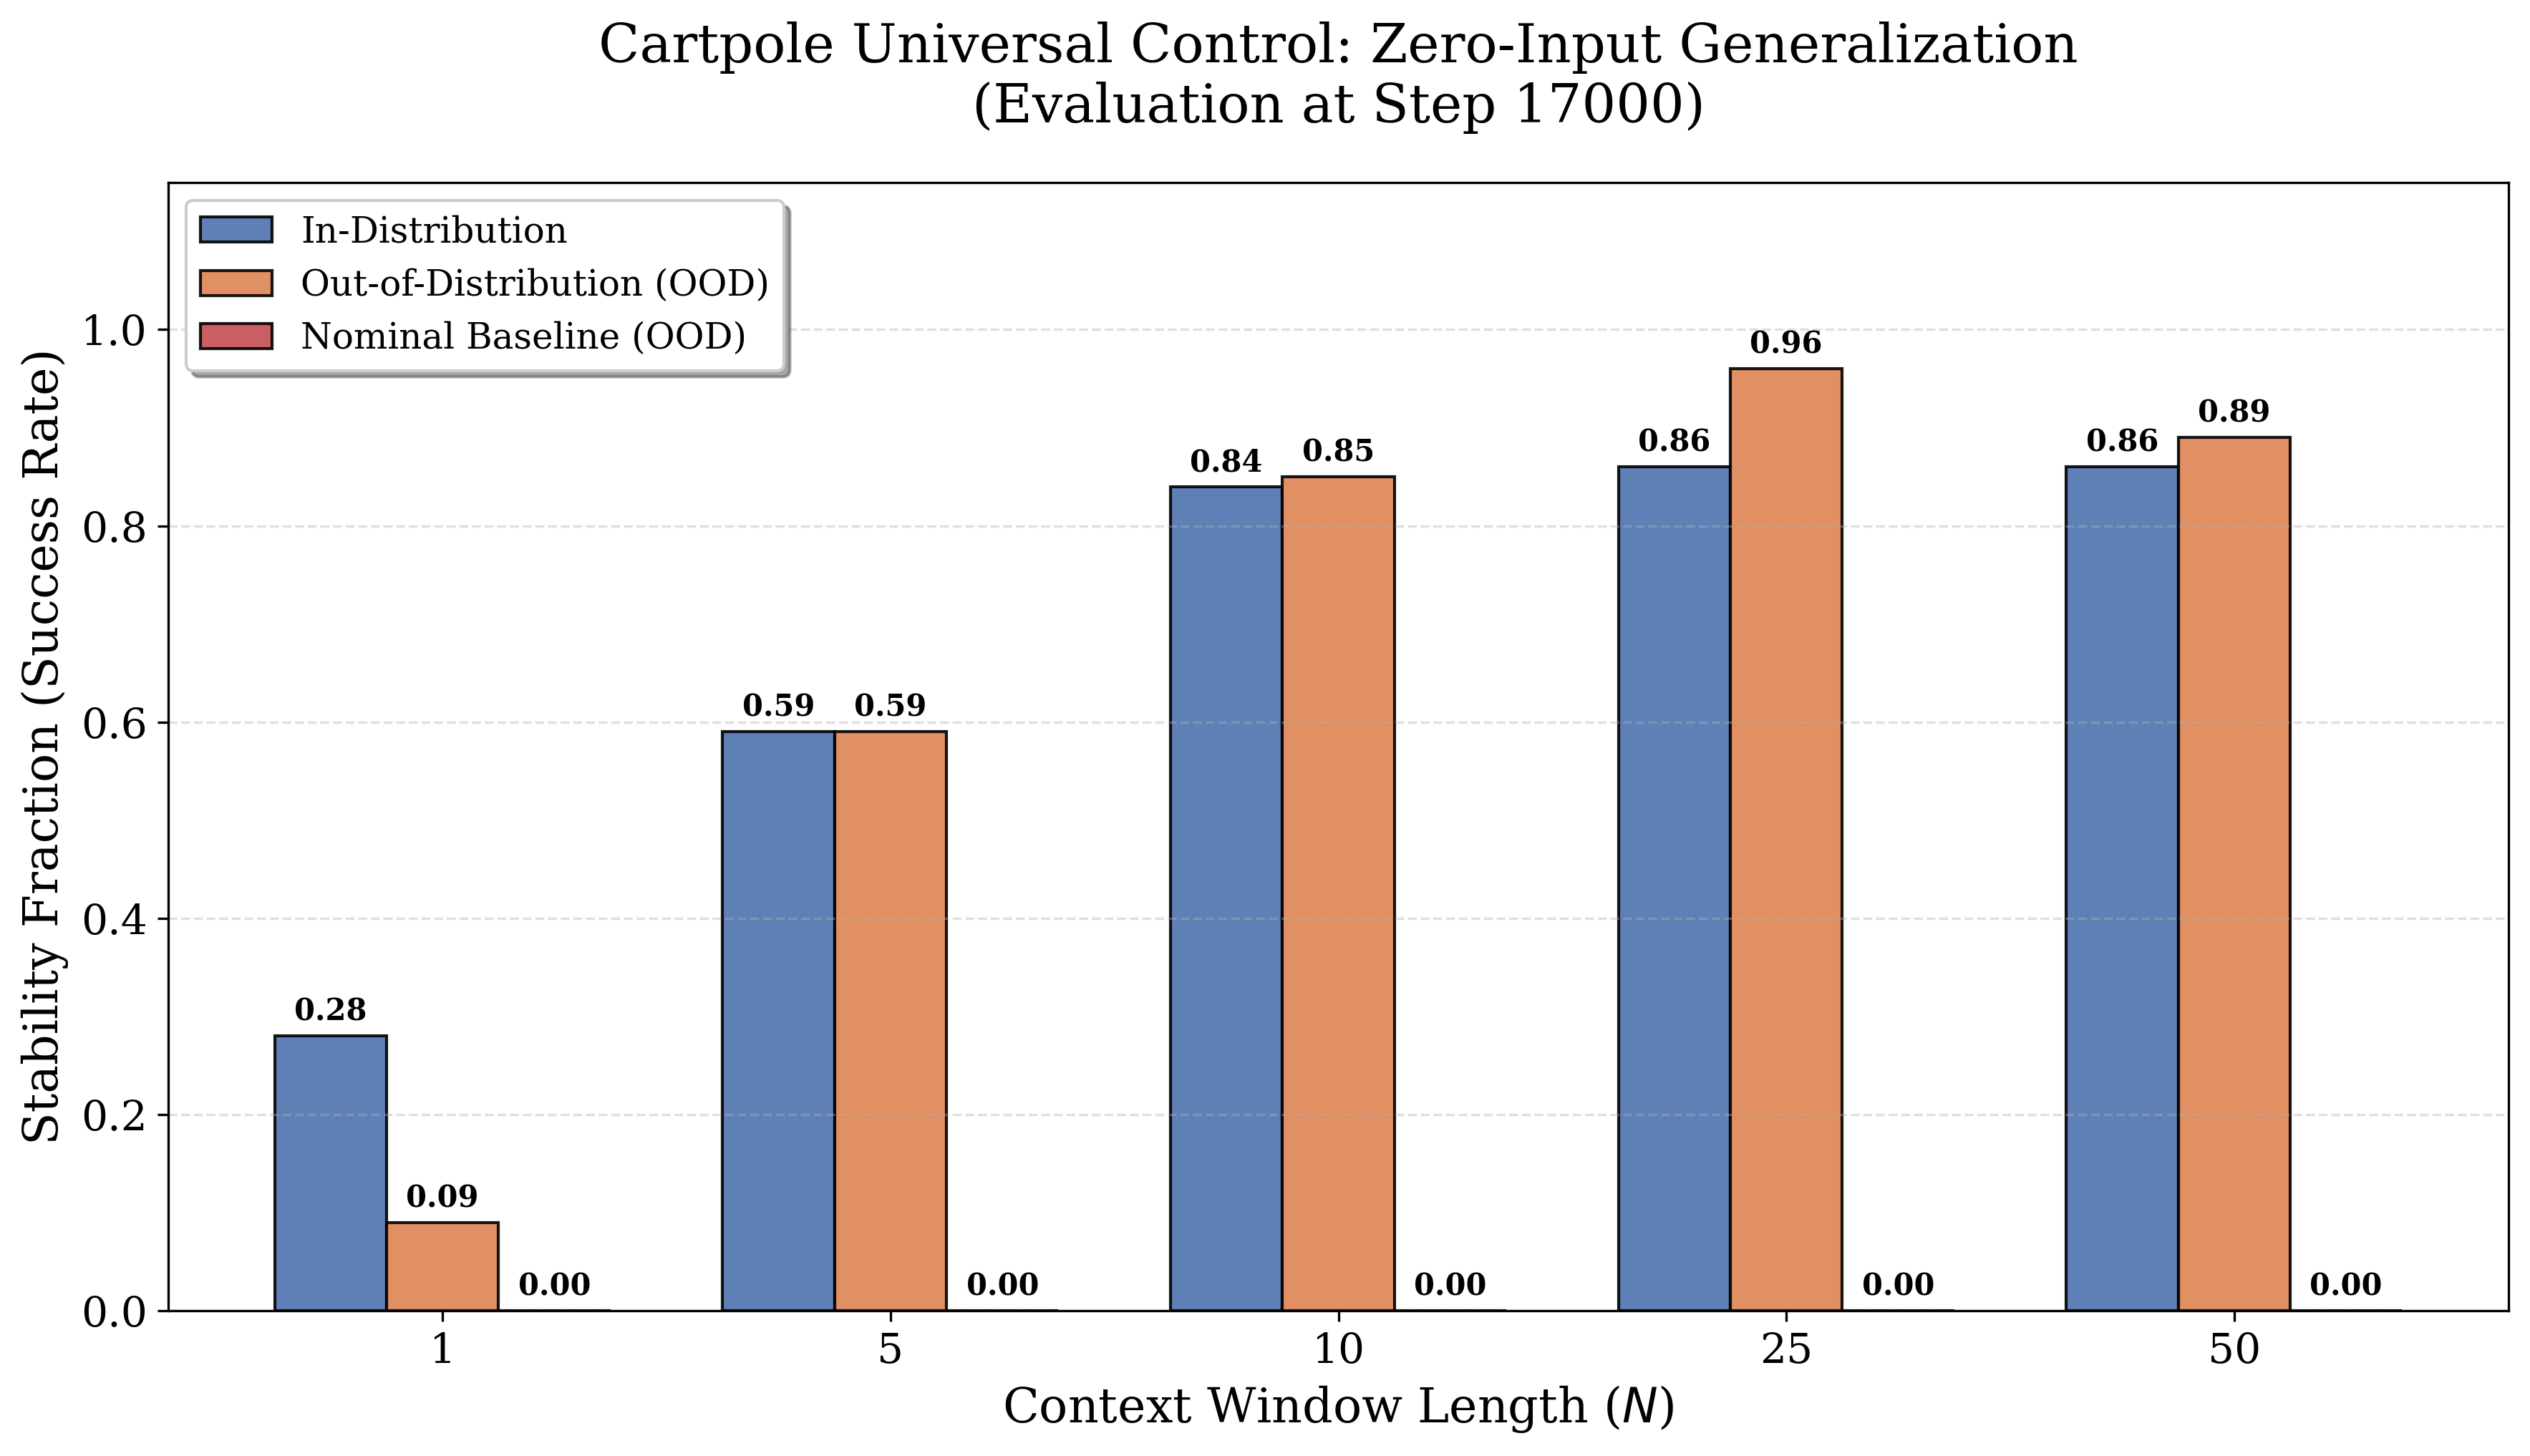

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# --- 1. SET PAPER-READY STYLING ---
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'font.family': 'serif',
    'figure.dpi': 300
})

# --- 2. PREPARE DATA ---
data2 = []
metric = 'stability_fraction'

for stp in steps_list2:
    for ctx in contexts:
        for mode in modes:
            val = results2[metric].get((stp, ctx, mode), 0.0)
            data2.append({
                'step': stp,
                'context': ctx,
                'mode': mode,
                'value': val
            })
        # Add Nominal Baseline (Hardcoded 0 as per your finding)
        data2.append({
            'step': stp,
            'context': ctx,
            'mode': 'nominal',
            'value': 0.0
        })

df_plot = pd.DataFrame(data2)
output_dir = "paper_plots_cartpole"
os.makedirs(output_dir, exist_ok=True)

# --- 3. PLOT GENERATION ---
for stp in steps_list2:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Filter and Sort
    step_data = df_plot[df_plot['step'] == stp]
    sorted_contexts = sorted(contexts)
    x = np.arange(len(sorted_contexts))
    width = 0.25  # Bar width
    
    # Define Categories and Colors
    # Blue: In-Distr, Orange: OOD, Red: Nominal (Failure)
    categories = [('indistr', 'In-Distribution', '#4C72B0'), 
                  ('ood', 'Out-of-Distribution (OOD)', '#DD8452'), 
                  ('nominal', 'Nominal Baseline (OOD)', '#C44E52')]

    for i, (mode_key, label, color) in enumerate(categories):
        vals = []
        for ctx in sorted_contexts:
            v = step_data[(step_data['context'] == ctx) & (step_data['mode'] == mode_key)]['value'].values
            vals.append(v[0] if len(v) > 0 else 0)
        
        offset = (i - 1) * width
        bars = ax.bar(x + offset, vals, width, label=label, color=color, edgecolor='black', alpha=0.9)
        
        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Formatting for Reviewers
    ax.set_ylabel('Stability Fraction (Success Rate)')
    ax.set_xlabel(r'Context Window Length ($N$)')
    ax.set_title(f'Cartpole Universal Control: Zero-Input Generalization\n(Evaluation at Step {stp})', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_contexts)
    ax.set_ylim(0, 1.15)
    ax.legend(loc='upper left', frameon=True, shadow=True)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    file_name = f'stability_comparison_step{stp}_paper.png'
    # plt.savefig(os.path.join(output_dir, file_name))
    print(f"Saved paper-ready plot: {file_name}")
    plt.show()